In [22]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Auto-detect the dataset root path
DATASET_ROOT = None

print("Searching for dataset...")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'Train.csv':
            DATASET_ROOT = dirname
            print(f"Success! Dataset root found at: {DATASET_ROOT}")
            break
    if DATASET_ROOT:
        break

if not DATASET_ROOT:
    print("ERROR: Train.csv not found. Did you attach the dataset to the notebook?")

Searching for dataset...
Success! Dataset root found at: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


In [23]:
def load_gtsrb_dataset(base_path, csv_name="Train.csv", target_size=(48, 48)):
    csv_path = os.path.join(base_path, csv_name)
    data = pd.read_csv(csv_path)
    
    images = []
    labels = []
    
    print(f"Loading {len(data)} images. This might take a minute...")
    
    for index, row in data.iterrows():
        img_path = os.path.join(base_path, row['Path'])
        img = cv2.imread(img_path)
        
        if img is not None:
            # OpenCV loads as BGR. Matplotlib expects RGB.
            # We must convert it now, or the colors will look completely wrong later.
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Standardize the size so algorithms work uniformly
            img_resized = cv2.resize(img_rgb, target_size)
            
            images.append(img_resized)
            labels.append(row['ClassId'])
            
    return np.array(images), np.array(labels)

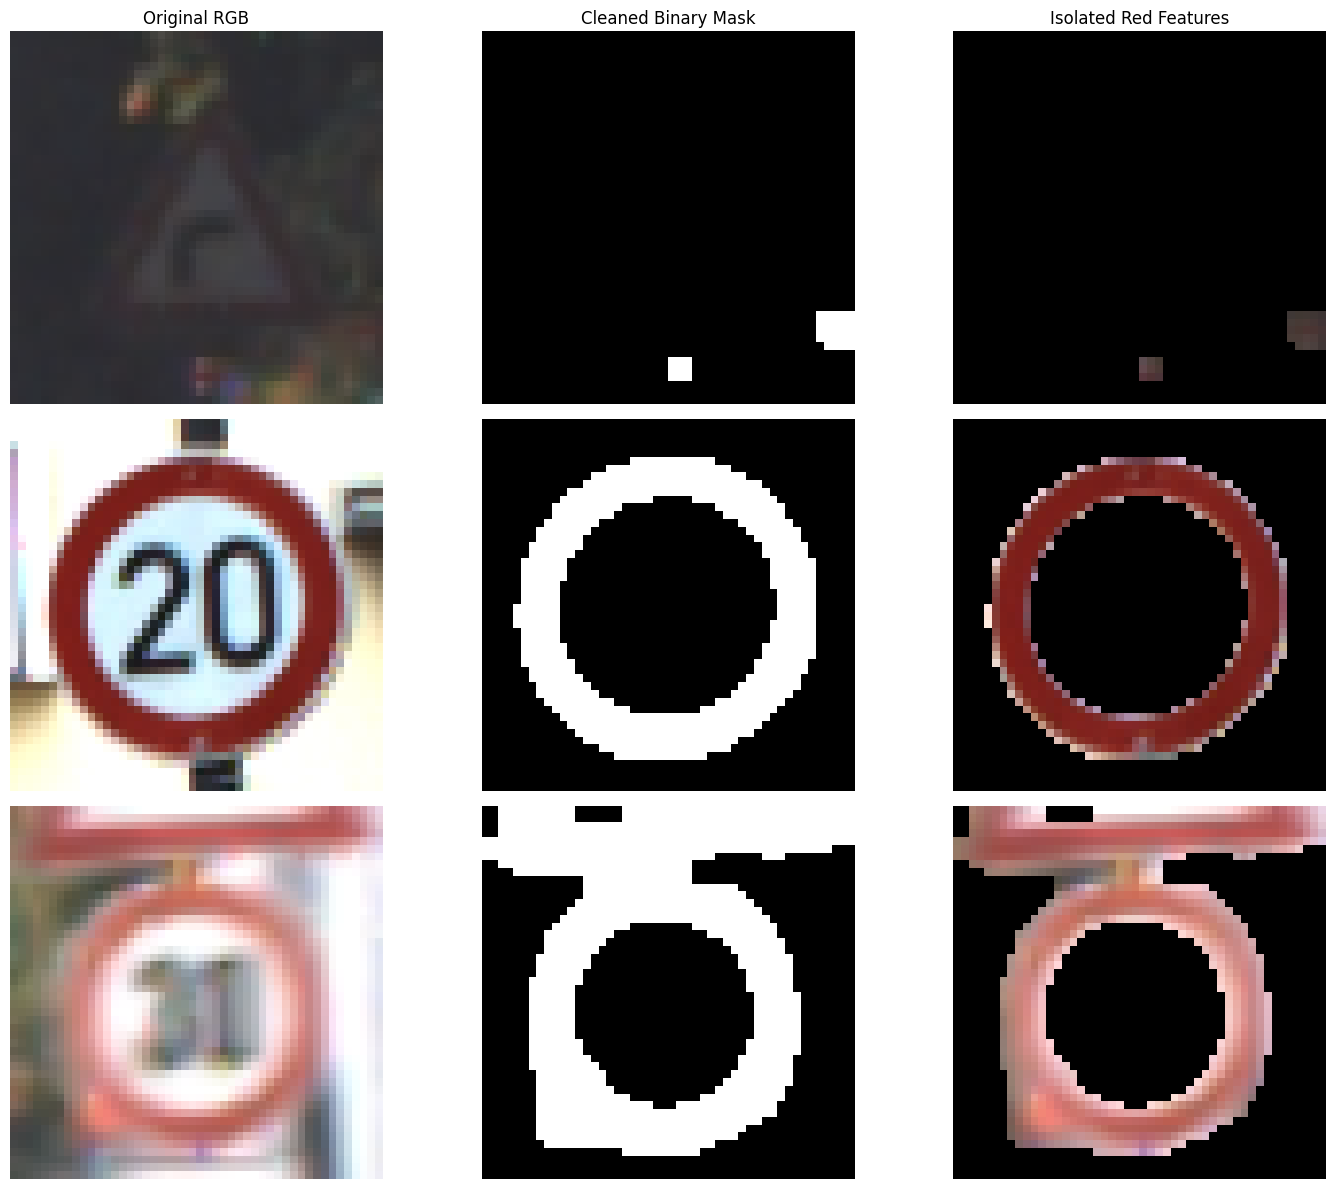

In [24]:
# ==========================================
# CELL 3: UPGRADED SEGMENTATION ENGINE
# ==========================================
def isolate_red_signs(image):
    # 1. PRE-PROCESSING: Apply Gaussian Blur to smooth out noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    hsv_image = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    # 2. COLOR THRESHOLDING (Using the wider, forgiving bounds)
    lower_red_1 = np.array([0, 40, 20])
    upper_red_1 = np.array([10, 255, 255])
    mask1 = cv2.inRange(hsv_image, lower_red_1, upper_red_1)
    
    lower_red_2 = np.array([160, 40, 20])
    upper_red_2 = np.array([180, 255, 255])
    mask2 = cv2.inRange(hsv_image, lower_red_2, upper_red_2)
    
    final_red_mask = cv2.bitwise_or(mask1, mask2)
    
    # 3. MORPHOLOGICAL CLEANUP
    # Create a 3x3 pixel kernel (a tiny sliding window)
    kernel = np.ones((3, 3), np.uint8)
    
    # MORPH_OPEN removes tiny specks of noise in the background
    final_red_mask = cv2.morphologyEx(final_red_mask, cv2.MORPH_OPEN, kernel)
    
    # MORPH_CLOSE fills in small holes inside the actual traffic sign mask
    final_red_mask = cv2.morphologyEx(final_red_mask, cv2.MORPH_CLOSE, kernel)
    
    red_isolated = cv2.bitwise_and(image, image, mask=final_red_mask)
    return final_red_mask, red_isolated

# ==========================================
# CELL 4: MULTI-IMAGE TESTING
# ==========================================
if len(train_images) > 0:
    # Let's test 3 different images to see how robust the new algorithm is
    test_indices = [10, 500, 1000] 
    
    fig, axes = plt.subplots(len(test_indices), 3, figsize=(15, 4 * len(test_indices)))
    
    for row, idx in enumerate(test_indices):
        test_img = train_images[idx]
        red_mask, red_isolated = isolate_red_signs(test_img)
        
        axes[row, 0].imshow(test_img)
        if row == 0: axes[row, 0].set_title("Original RGB")
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(red_mask, cmap='gray')
        if row == 0: axes[row, 1].set_title("Cleaned Binary Mask")
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(red_isolated)
        if row == 0: axes[row, 2].set_title("Isolated Red Features")
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()

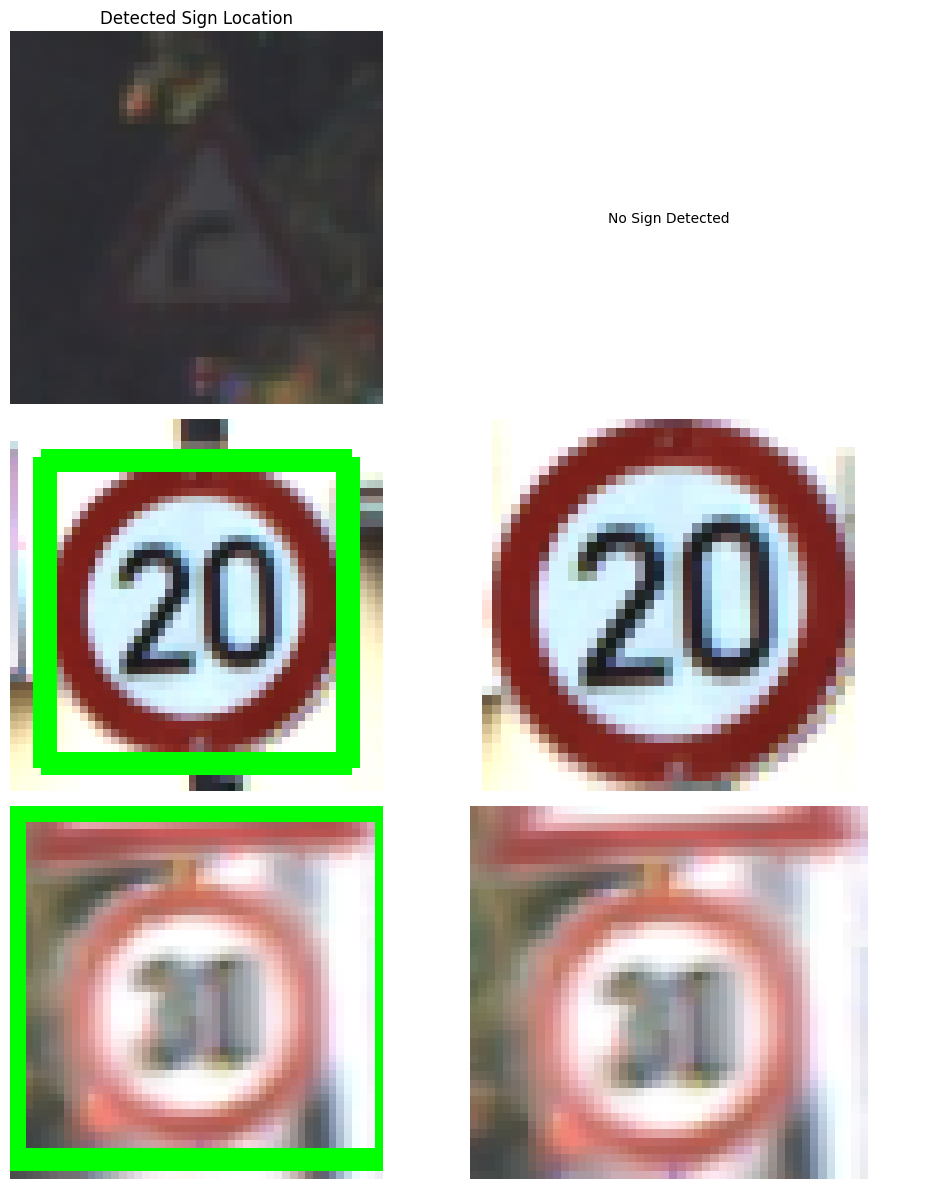

In [25]:
# ==========================================
# CELL 5: SHAPE DETECTION (CONTOURS & ROI)
# ==========================================

def extract_sign_roi(image, mask):
    """
    Finds the largest contour in the mask and extracts the Region of Interest (ROI).
    """
    # 1. Find contours in the binary mask
    # RETR_EXTERNAL gets only the outer outlines, CHAIN_APPROX_SIMPLE compresses the data
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return None, image.copy()
        
    # 2. Filter contours to find the largest one (assuming it's the sign)
    largest_contour = max(contours, key=cv2.contourArea)
    
    # 3. Area threshold: Ignore it if the largest blob is just a tiny speck of noise
    if cv2.contourArea(largest_contour) < 50:
         return None, image.copy()
    
    # 4. Get the bounding box coordinates for that contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # 5. Extract the Region of Interest (ROI) from the ORIGINAL image
    roi = image[y:y+h, x:x+w]
    
    # 6. Draw a green rectangle on a copy of the original image for visualization
    image_with_box = image.copy()
    cv2.rectangle(image_with_box, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    return roi, image_with_box

# ==========================================
# TEST CONTROURS ON OUR 3 IMAGES
# ==========================================
if len(train_images) > 0:
    test_indices = [10, 500, 1000] 
    fig, axes = plt.subplots(len(test_indices), 2, figsize=(10, 4 * len(test_indices)))
    
    for row, idx in enumerate(test_indices):
        test_img = train_images[idx]
        
        # 1. Get the mask from our previous function
        red_mask, _ = isolate_red_signs(test_img)
        
        # 2. Extract the ROI and bounding box
        roi, image_with_box = extract_sign_roi(test_img, red_mask)
        
        # Plotting Original with Box
        axes[row, 0].imshow(image_with_box)
        if row == 0: axes[row, 0].set_title("Detected Sign Location")
        axes[row, 0].axis('off')
        
        # Plotting Cropped ROI
        if roi is not None:
            axes[row, 1].imshow(roi)
            if row == 0: axes[row, 1].set_title("Extracted ROI")
        else:
            axes[row, 1].text(0.5, 0.5, 'No Sign Detected', ha='center', va='center')
            
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [27]:
# ==========================================
# CELL 6: FEATURE MATCHING (ORB)
# ==========================================

def load_reference_images(dataset_path):
    """Loads idealized reference images from the Meta folder to use as a dictionary."""
    meta_csv_path = os.path.join(dataset_path, 'Meta.csv')
    meta_data = pd.read_csv(meta_csv_path)
    
    references = {}
    print("Loading reference dictionary...")
    for index, row in meta_data.iterrows():
        img_path = os.path.join(dataset_path, row['Path'])
        img = cv2.imread(img_path)
        
        if img is not None:
            # Feature matching works best in grayscale
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Resize to a slightly larger standard size so ORB finds enough keypoints
            references[row['ClassId']] = cv2.resize(img_gray, (100, 100))
            
    return references

def classify_sign(roi, references):
    """Uses ORB to find the reference image with the most matching keypoints."""
    # Convert ROI to grayscale and resize to match reference dictionary
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    roi_gray = cv2.resize(roi_gray, (100, 100))
    
    # Initialize ORB detector
    orb = cv2.ORB_create(nfeatures=200)
    
    # Find keypoints and descriptors in our cropped sign
    kp1, des1 = orb.detectAndCompute(roi_gray, None)
    
    # If the ROI is completely blank/blurry, ORB might find 0 features
    if des1 is None:
        return "Unknown", 0
        
    # Initialize Brute-Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    
    best_class_id = -1
    max_matches = 0
    
    # Compare our ROI against every single reference image
    for class_id, ref_img in references.items():
        kp2, des2 = orb.detectAndCompute(ref_img, None)
        
        if des2 is not None:
            matches = bf.match(des1, des2)
            
            if len(matches) > max_matches:
                max_matches = len(matches)
                best_class_id = class_id
                
    return best_class_id, max_matches

# ==========================================
# EXECUTE THE FULL PIPELINE
# ==========================================
# 1. Load the dictionary
reference_dict = load_reference_images(DATASET_ROOT)

# 2. Test it on our successful ROIs (Images 500 and 1000)
if len(train_images) > 0:
    test_indices = [500, 1000] # Skipping 10 since we know it's too dark
    
    for idx in test_indices:
        test_img = train_images[idx]
        actual_label = train_labels[idx]
        
        # Phase A: Segment
        red_mask, _ = isolate_red_signs(test_img)
        
        # Phase B: Crop
        roi, _ = extract_sign_roi(test_img, red_mask)
        
        # Phase C: Match
        if roi is not None:
            predicted_class, match_count = classify_sign(roi, reference_dict)
            
            print("-" * 30)
            print(f"Testing Image Index: {idx}")
            print(f"Actual Class ID:   {actual_label}")
            print(f"Predicted Class:   {predicted_class}")
            print(f"Keypoints Matched: {match_count}")
        else:
            print(f"Image {idx}: Segmentation failed, no ROI extracted.")

Loading reference dictionary...
------------------------------
Testing Image Index: 500
Actual Class ID:   0
Predicted Class:   41
Keypoints Matched: 19
------------------------------
Testing Image Index: 1000
Actual Class ID:   1
Predicted Class:   14
Keypoints Matched: 8
